# 07 — Validation

Post-optimization validation of the best design:
1. Load optimized design
2. Full AVL re-evaluation with control surfaces
3. **Geometry visualization** (planform, airfoils, front view)
4. Alpha polar
5. Stability & control authority
6. Propulsion balance at multiple speeds

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.parameterization.design_variables import BWBParams, params_from_vector
from src.parameterization.bwb_aircraft import (
    build_airplane, build_body_kulfan_at_station, build_kulfan_airfoil_at_station,
    compute_wing_area, compute_aspect_ratio, compute_mac,
    compute_internal_volume, estimate_structural_mass,
    OUTER_WING_STATIONS, N_OUTER_SEGMENTS,
)
from src.aero.evaluator import AeroEvaluator
from src.config import load_all
from src.systems.cg import compute_cg
from src.propulsion.edf_model import EDF_70MM, thrust_at_speed, endurance as compute_endurance

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
from src.visualization.style import apply_style, COLORS
apply_style()

In [2]:
%load_ext autoreload
%autoreload 2

## 1. Load Best Design

In [3]:
# Load optimized design
try:
    best_x = np.load('../output/best_x_v2.npy')
    best_params = params_from_vector(best_x)
    print('Loaded optimized design')
except FileNotFoundError:
    best_params = BWBParams()
    print('No optimized design found, using defaults')

cfg = load_all()
mission = cfg['mission']
evaluator = AeroEvaluator(
    mission=mission, feasibility=cfg['feasibility'],
    controls=cfg['controls'], cg_config=cfg['cg'],
    avl_command=cfg['avl_command'],
    aero_model=cfg['aero_model'], structure_config=cfg['structure'],
    use_cg=True,
)

Loaded optimized design


## 2. Full VLM Re-evaluation

In [4]:
result = evaluator.evaluate(best_params)

print('=== Full AVL Evaluation (v2: real CG + elevon trim) ===\n')
print('Aerodynamics:')
for key in ['L_over_D', 'CL', 'CD', 'CD0_wing', 'CD0_body', 'CDi', 'CD_trim',
            'CM', 'alpha_eq', 'static_margin', 'oswald_e', 'AR', 'S_ref']:
    val = result.get(key, 'N/A')
    if key == 'static_margin':
        print(f'  {key:20s} = {val:.4f} ({val*100:.1f}% MAC)')
    elif isinstance(val, float):
        print(f'  {key:20s} = {val:.4f}')

print('\nStability & Control:')
for key in ['Cn_beta', 'Cl_beta', 'elevon_deflection', 'CL_de', 'Cm_de', 'Cl_da', 'Cn_da']:
    val = result.get(key, 'N/A')
    if isinstance(val, float):
        print(f'  {key:20s} = {val:.5f}')

print('\nCG & Mass:')
print(f'  {"x_cg":20s} = {result.get("x_cg", 0)*100:.1f} cm (x/c = {result.get("x_cg_frac", 0):.3f})')
print(f'  {"struct_mass":20s} = {result["struct_mass"]*1000:.0f} g')
print(f'  {"internal_volume":20s} = {result["internal_volume"]*1e6:.0f} cm3')

print('\nPropulsion:')
for key in ['T_over_D', 'P_elec', 'endurance_min', 'range_km', 'duct_fits']:
    val = result.get(key, 'N/A')
    if isinstance(val, float):
        print(f'  {key:20s} = {val:.2f}')
    else:
        print(f'  {key:20s} = {val}')

print(f'\n  {"is_feasible":20s} = {result["is_feasible"]}')
print(f'  {"penalty":20s} = {result["penalty"]:.4f}')

=== Full AVL Evaluation (v2: real CG + elevon trim) ===

Aerodynamics:
  L_over_D             = 19.3180
  CL                   = 0.0690
  CD                   = 0.0158
  CD0_wing             = 0.0039
  CD0_body             = 0.0097
  CDi                  = 0.0003
  CD_trim              = 0.0002
  CM                   = -0.0000
  alpha_eq             = 3.3482
  static_margin        = 0.2150 (21.5% MAC)
  oswald_e             = 0.8041
  AR                   = 6.6238
  S_ref                = 0.2119

Stability & Control:
  Cn_beta              = 0.00323
  Cl_beta              = -0.08021
  elevon_deflection    = -15.17598
  CL_de                = 0.01567
  Cm_de                = -0.00699
  Cl_da                = -0.00158
  Cn_da                = 0.00010

CG & Mass:
  x_cg                 = 19.2 cm (x/c = 0.457)
  struct_mass          = 581 g
  internal_volume      = 845 cm3

Propulsion:
  T_over_D             = 1.88
  P_elec               = 81.47
  endurance_min        = 10.15
  range_km   

## 4. Alpha Polar

## 3. Geometry Visualization

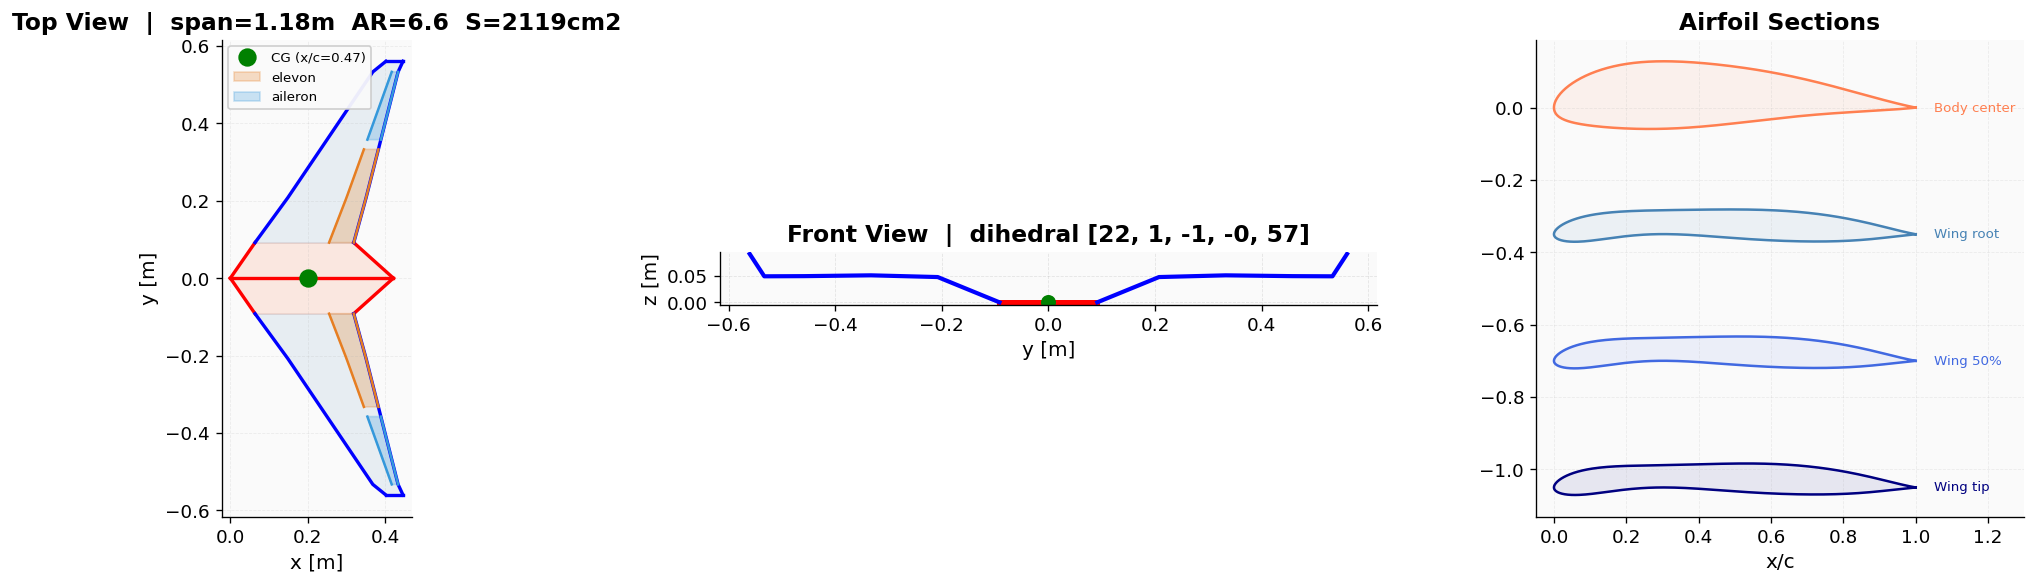

Saved: output/v2_geometry_overview.png


In [5]:
p = best_params
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Compute geometry ──
body_sweep_rad = np.radians(p.body_sweep_deg)
wing_sweep_rad = np.radians(p.le_sweep_deg)
bw = p.body_halfwidth
outer_span = p.outer_half_span
from src.parameterization.bwb_aircraft import outer_wing_dihedrals
dihedrals = outer_wing_dihedrals(p)

# Body LE/TE
body_le = [[0, 0], [bw*0.5*np.tan(body_sweep_rad), bw*0.5],
           [bw*np.tan(body_sweep_rad), bw]]
body_te = [[p.body_root_chord, 0],
           [(p.body_root_chord+p.wing_root_chord)/2 + bw*0.5*np.tan(body_sweep_rad), bw*0.5],
           [p.wing_root_chord + bw*np.tan(body_sweep_rad), bw]]

# Outer wing LE with dihedral
x_blend = bw * np.tan(body_sweep_rad)
wing_le = [[x_blend, bw, 0]]
for i in range(N_OUTER_SEGMENTS):
    prev = wing_le[-1]
    dy_seg = outer_span * (OUTER_WING_STATIONS[i+1] - OUTER_WING_STATIONS[i])
    dih_rad = np.radians(dihedrals[i])
    wing_le.append([prev[0] + dy_seg*np.tan(wing_sweep_rad),
                    prev[1] + dy_seg*np.cos(dih_rad),
                    prev[2] + dy_seg*np.sin(dih_rad)])

chords = [p.wing_root_chord + f*(p.tip_chord - p.wing_root_chord) for f in OUTER_WING_STATIONS]
wing_te = [[le[0]+c, le[1], le[2]] for le, c in zip(wing_le, chords)]

# CG position
from src.systems.cg import CGConfig
cg_data = compute_cg(p, mission.battery_mass, mission.motor_mass, mission.avionics_mass, CGConfig())

# Control surface geometry via dedicated module
from src.geometry.control_surfaces import compute_control_surface_geometry
from src.aero.avl_runner import ControlConfig
geoms = compute_control_surface_geometry(p, ControlConfig.default_bwb())

# ═══ TOP VIEW ═══
ax = axes[0]
for sign in [1, -1]:
    by = [pt[1]*sign for pt in body_le]
    ax.fill_betweenx(by, [pt[0] for pt in body_le], [pt[0] for pt in body_te], alpha=0.15, color='coral')
    ax.plot([pt[0] for pt in body_le], by, 'r-', lw=2)
    ax.plot([pt[0] for pt in body_te], by, 'r-', lw=2)

    wy = [pt[1]*sign for pt in wing_le]
    ax.fill_betweenx(wy, [pt[0] for pt in wing_le], [pt[0] for pt in wing_te], alpha=0.1, color='steelblue')
    ax.plot([pt[0] for pt in wing_le], wy, 'b-', lw=2)
    ax.plot([pt[0] for pt in wing_te], wy, 'b-', lw=2)
    ax.plot([wing_le[-1][0], wing_te[-1][0]], [wy[-1], wy[-1]], 'b-', lw=2)

ax.plot([0, p.body_root_chord], [0, 0], 'r-', lw=2)

# CG marker
ax.plot(cg_data['x_cg'], 0, 'go', ms=10, zorder=5, label=f'CG (x/c={cg_data["x_cg_frac"]:.2f})')

# Control surfaces from compute_control_surface_geometry
cs_colors = {'elevon': '#e67e22', 'aileron': '#3498db'}
for g in geoms:
    color = cs_colors.get(g.name, 'gray')
    for sign in [1, -1]:
        # Hinge line
        ax.plot(g.hinge_line_upper[:, 0], g.hinge_line_upper[:, 1] * sign,
                '-', color=color, lw=1.5)
        # TE line
        ax.plot(g.te_line_upper[:, 0], g.te_line_upper[:, 1] * sign,
                '-', color=color, lw=1.5)
        # Fill between hinge and TE
        ax.fill(
            np.concatenate([g.hinge_line_upper[:, 0], g.te_line_upper[::-1, 0]]),
            np.concatenate([g.hinge_line_upper[:, 1], g.te_line_upper[::-1, 1]]) * sign,
            alpha=0.25, color=color, label=g.name if sign == 1 else None,
        )

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Top View  |  span={2*p.half_span:.2f}m  AR={compute_aspect_ratio(p):.1f}  S={compute_wing_area(p)*1e4:.0f}cm2')
ax.set_aspect('equal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ═══ FRONT VIEW ═══
ax2 = axes[1]
for sign in [1, -1]:
    ax2.plot([0, bw*sign], [0, 0], 'r-', lw=3)
    wy = [pt[1]*sign for pt in wing_le]
    wz = [pt[2] for pt in wing_le]
    ax2.plot(wy, wz, 'b-', lw=2.5)
ax2.plot(0, 0, 'go', ms=8)
ax2.set_xlabel('y [m]')
ax2.set_ylabel('z [m]')
ax2.set_title(f'Front View  |  dihedral [{p.dihedral_0:.0f}, {p.dihedral_1:.0f}, '
              f'{p.dihedral_2:.0f}, {p.dihedral_3:.0f}, {p.dihedral_tip:.0f}]')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# ═══ AIRFOIL SECTIONS ═══
ax3 = axes[2]
sections = [
    ('Body center', build_body_kulfan_at_station(p, 0.0).to_airfoil(), 'coral'),
    ('Wing root', build_kulfan_airfoil_at_station(p, 0.0).to_airfoil(), 'steelblue'),
    ('Wing 50%', build_kulfan_airfoil_at_station(p, 0.5).to_airfoil(), 'royalblue'),
    ('Wing tip', build_kulfan_airfoil_at_station(p, 1.0).to_airfoil(), 'navy'),
]
for i, (label, af, color) in enumerate(sections):
    coords = af.coordinates
    offset = -i * 0.35
    ax3.plot(coords[:, 0], coords[:, 1] + offset, color=color, lw=1.5)
    ax3.fill(coords[:, 0], coords[:, 1] + offset, alpha=0.08, color=color)
    ax3.text(1.05, offset, label, fontsize=8, va='center', color=color)

ax3.set_xlabel('x/c')
ax3.set_title('Airfoil Sections')
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.2)
ax3.set_xlim(-0.05, 1.3)

plt.tight_layout()
plt.savefig('../output/v2_geometry_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/v2_geometry_overview.png')

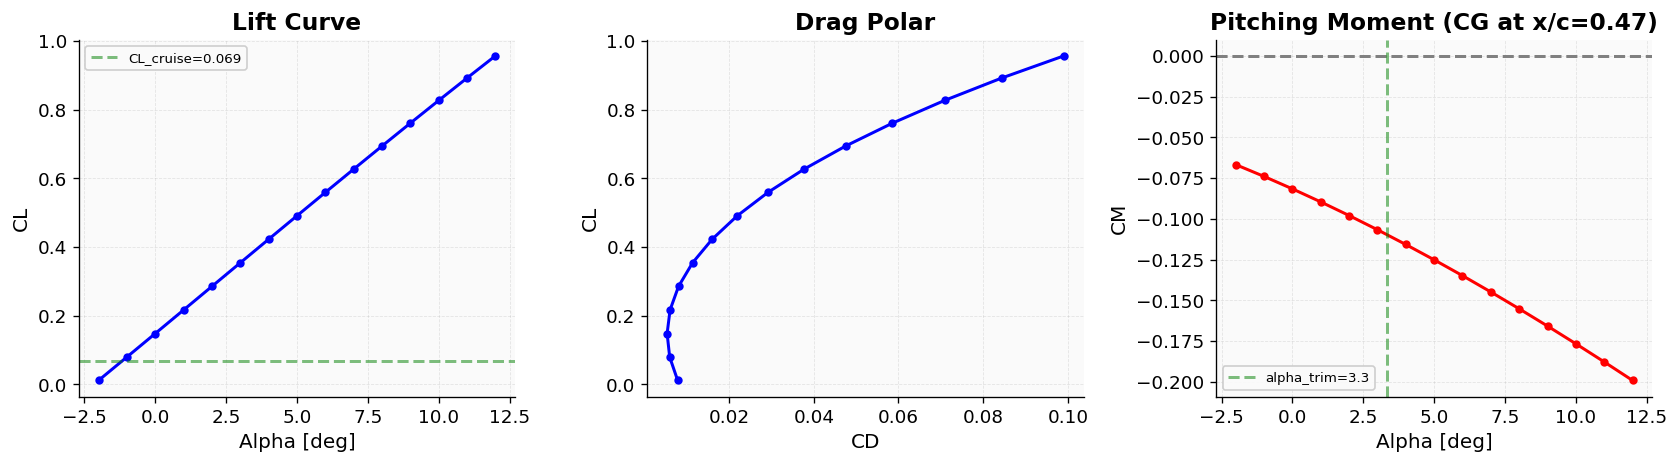

In [6]:
airplane = build_airplane(best_params, x_cg=cg_data['x_cg'])
import aerosandbox as asb

alphas = np.linspace(-2, 12, 15)
cls, cds, cms = [], [], []

for alpha in alphas:
    op = asb.OperatingPoint(
        atmosphere=mission.atmosphere,
        velocity=mission.velocity,
        alpha=alpha,
    )
    vlm = asb.VortexLatticeMethod(airplane=airplane, op_point=op,
                                   chordwise_resolution=4, spanwise_resolution=10)
    aero = vlm.run()
    cls.append(aero['CL'])
    cds.append(aero['CD'])
    cms.append(aero['Cm'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(alphas, cls, 'b-o', ms=4)
axes[0].axhline(result['CL'], color='green', ls='--', alpha=0.5, label=f'CL_cruise={result["CL"]:.3f}')
axes[0].set_xlabel('Alpha [deg]')
axes[0].set_ylabel('CL')
axes[0].set_title('Lift Curve')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cds, cls, 'b-o', ms=4)
axes[1].set_xlabel('CD')
axes[1].set_ylabel('CL')
axes[1].set_title('Drag Polar')
axes[1].grid(True, alpha=0.3)

axes[2].plot(alphas, cms, 'r-o', ms=4)
axes[2].set_xlabel('Alpha [deg]')
axes[2].set_ylabel('CM')
axes[2].set_title(f'Pitching Moment (CG at x/c={cg_data["x_cg_frac"]:.2f})')
axes[2].axhline(0, color='gray', ls='--')
axes[2].axvline(result['alpha_eq'], color='green', ls='--', alpha=0.5, label=f'alpha_trim={result["alpha_eq"]:.1f}')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Propulsion Balance vs Speed

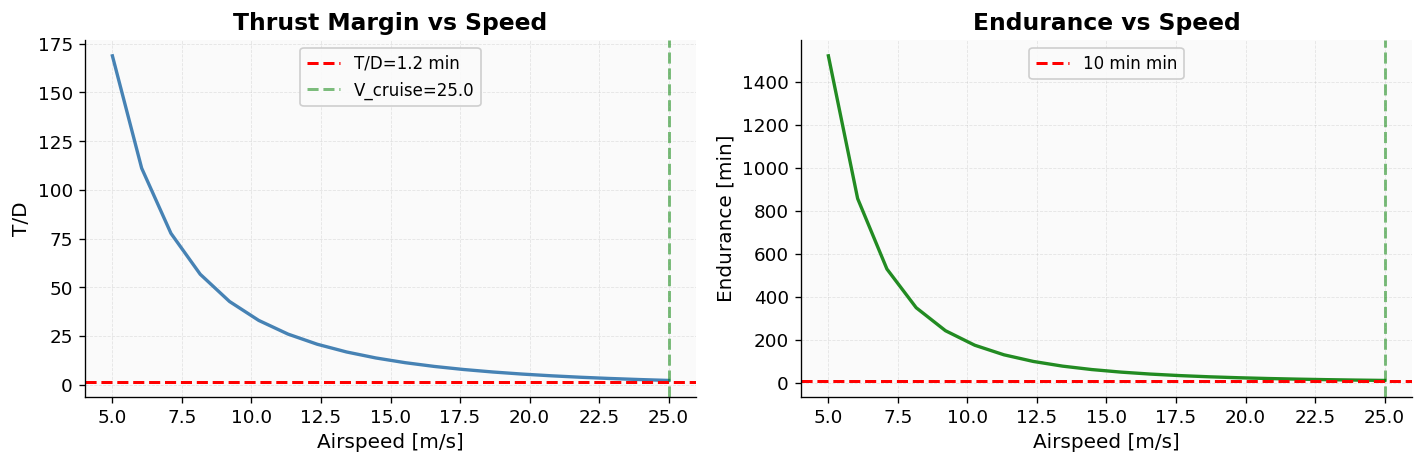

In [7]:
speeds = np.linspace(5, 25, 20)
s_ref = compute_wing_area(best_params)
td_ratios = []
endurances = []

for v in speeds:
    q = 0.5 * mission.density * v**2
    cl_req = mission.weight / (q * s_ref)
    cd_approx = result['CD']  # simplified: use same CD
    drag = cd_approx * q * s_ref
    t_avail = thrust_at_speed(EDF_70MM, v)
    td_ratios.append(t_avail / drag if drag > 0 else 0)
    e = compute_endurance(drag, v, EDF_70MM, mission.battery)
    endurances.append(e['endurance_min'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(speeds, td_ratios, 'steelblue', lw=2)
axes[0].axhline(1.2, color='red', ls='--', label='T/D=1.2 min')
axes[0].axvline(mission.velocity, color='green', ls='--', alpha=0.5, label=f'V_cruise={mission.velocity}')
axes[0].set_xlabel('Airspeed [m/s]')
axes[0].set_ylabel('T/D')
axes[0].set_title('Thrust Margin vs Speed')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(speeds, endurances, 'forestgreen', lw=2)
axes[1].axhline(10, color='red', ls='--', label='10 min min')
axes[1].axvline(mission.velocity, color='green', ls='--', alpha=0.5)
axes[1].set_xlabel('Airspeed [m/s]')
axes[1].set_ylabel('Endurance [min]')
axes[1].set_title('Endurance vs Speed')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5b. Drag Breakdown & Propulsion Balance

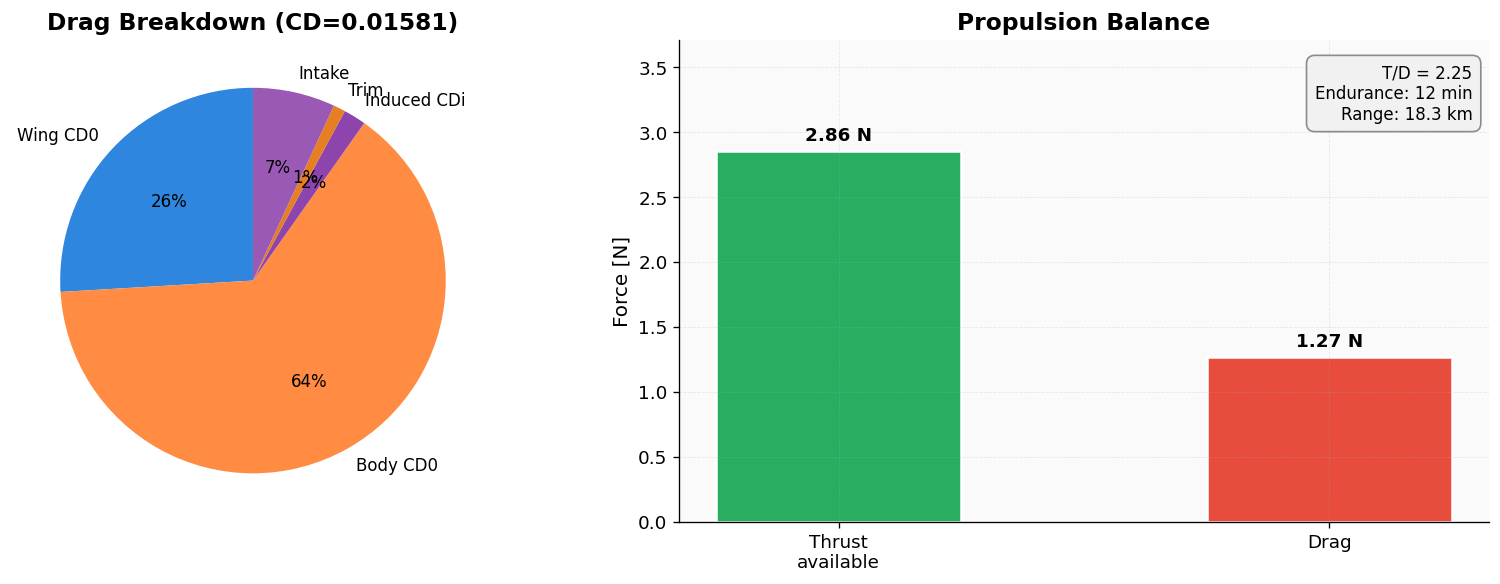

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Drag decomposition pie ---
cd0w = result['CD0_wing']
cd0b = result['CD0_body']
cdi = result['CDi']
cd_trim = result.get('CD_trim', 0)
cd_intake = mission.intake_cd(result['S_ref'])
cd_total = result['CD']

drag_labels = ['Wing CD0', 'Body CD0', 'Induced CDi', 'Trim', 'Intake']
drag_values = [cd0w, cd0b, cdi, cd_trim, cd_intake]
drag_colors = [COLORS['wing'], COLORS['body'], COLORS['accent'],
               COLORS['elevon'], COLORS['duct']]

# Filter out near-zero components
mask = [v > 1e-6 for v in drag_values]
drag_labels = [l for l, m in zip(drag_labels, mask) if m]
drag_values = [v for v, m in zip(drag_values, mask) if m]
drag_colors = [c for c, m in zip(drag_colors, mask) if m]

ax1.pie(drag_values, labels=drag_labels, colors=drag_colors,
        autopct=lambda p: f'{p:.0f}%', startangle=90,
        textprops={'fontsize': 10})
ax1.set_title(f'Drag Breakdown (CD={cd_total:.5f})', fontsize=14, fontweight='bold')

# --- Propulsion balance bar ---
from src.visualization.plots import plot_propulsion_balance as _ppb

t_avail = mission.thrust_available
drag_force = cd_total * mission.dynamic_pressure * result['S_ref']
prop = mission.propulsion_balance(drag_force)

bar_labels = ['Thrust\navailable', 'Drag']
bar_values = [t_avail, drag_force]
bar_colors = [COLORS['thrust'], COLORS['drag']]

bars = ax2.bar(bar_labels, bar_values, color=bar_colors, width=0.5,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, bar_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f} N', ha='center', va='bottom', fontsize=11, fontweight='bold')

surplus = t_avail - drag_force
props = dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='gray', alpha=0.9)
text = f'T/D = {t_avail/drag_force:.2f}\nEndurance: {prop["endurance_min"]:.0f} min\nRange: {prop["range_km"]:.1f} km'
ax2.text(0.98, 0.95, text, transform=ax2.transAxes, fontsize=10,
         va='top', ha='right', bbox=props)
ax2.set_ylabel('Force [N]')
ax2.set_title('Propulsion Balance', fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(t_avail, drag_force) * 1.3)

plt.tight_layout()
plt.savefig('../output/drag_propulsion_balance.png', dpi=150, bbox_inches='tight')
plt.show()